In [1]:
# 2. Imports and Config
import os, json, random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import clip
from segment_anything import sam_model_registry

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

class Config:
    DATASET_DIR = "cracks_dataset_v2"  # Make sure this is in your directory
    PROMPTS = ["segment crack", "segment wall crack"]
    IMAGE_SIZE = 224
    BATCH_SIZE = 4
    NUM_EPOCHS = 10
    LEARNING_RATE = 1e-4
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

cfg = Config()
print(f"Using Accelerated Device: {cfg.DEVICE}")

/home/nagendra/anaconda3/envs/crk/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using Accelerated Device: cuda


In [2]:
# 3. Resilient Fast Dataset
class CrackDataset(Dataset):
    def __init__(self, split, dataset_dir, prompts, image_size=224):
        self.split, self.prompts, self.image_size = split, prompts, image_size
        self.dataset_dir = dataset_dir
        with open(os.path.join(dataset_dir, "metadata.json"), "r") as f:
            metadata = json.load(f)
        
        self.samples = []
        for m in metadata["images"]:
            if m["split"] == split:
                if os.path.exists(os.path.join(dataset_dir, split, "masks", m["mask_file"])):
                    self.samples.append(m)
        print(f"{split.upper()}:	Loaded {len(self.samples)} completely healthy images.")

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]
        img = Image.open(os.path.join(self.dataset_dir, self.split, "images", sample["image_file"])).convert("RGB")
        mask = Image.open(os.path.join(self.dataset_dir, self.split, "masks", sample["mask_file"])).convert("L")
        img = img.resize((self.image_size, self.image_size), Image.BILINEAR)
        mask = mask.resize((self.image_size, self.image_size), Image.NEAREST)
        
        img_t = transforms.ToTensor()(img)
        mask_t = torch.from_numpy(np.array(mask)).float() / 255.0
        return img_t, mask_t, random.choice(self.prompts)

train_ds = CrackDataset("train", cfg.DATASET_DIR, cfg.PROMPTS, cfg.IMAGE_SIZE)
val_ds = CrackDataset("val", cfg.DATASET_DIR, cfg.PROMPTS, cfg.IMAGE_SIZE)
test_ds = CrackDataset("test", cfg.DATASET_DIR, cfg.PROMPTS, cfg.IMAGE_SIZE)

# SUPER CRITICAL: Train gets fast workers. Val/Test get 0 to explicitly prevent Linux deadlock after progress bar finishes.
train_loader = DataLoader(train_ds, batch_size=cfg.BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True, persistent_workers=True)
val_loader = DataLoader(val_ds, batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=4)
test_loader = DataLoader(test_ds, batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=4)

TRAIN:	Loaded 3756 completely healthy images.
VAL:	Loaded 805 completely healthy images.
TEST:	Loaded 806 completely healthy images.


In [3]:
# 4. Metrics Evaluator
def compute_metrics(p_mask, t_mask, threshold=0.5):
    p = (p_mask > threshold).float()
    t = (t_mask > threshold).float()
    inter = (p * t).sum()
    
    precision = (inter + 1e-8) / (p.sum() + 1e-8)
    recall = (inter + 1e-8) / (t.sum() + 1e-8)
    iou = (inter + 1e-8) / (p.sum() + t.sum() - inter + 1e-8)
    f1 = 2 * precision * recall / (precision + recall + 1e-8)
    dice = (2 * inter + 1e-8) / (p.sum() + t.sum() + 1e-8)
    
    return {
        "iou": iou.item(), "precision": precision.item(), 
        "recall": recall.item(), "f1": f1.item(), "dice": dice.item()
    }

def run_batch_metrics(preds, targets):
    metrics = {"iou": [], "precision": [], "recall": [], "f1": [], "dice": []}
    for p, t in zip(preds, targets):
        res = compute_metrics(p, t)
        for k in metrics: metrics[k].append(res[k])
        
    return {
        "IoU": np.mean(metrics["iou"]),
        "mIoU": np.mean(metrics["iou"]), # Equivalent in this classification scope
        "Precision": np.mean(metrics["precision"]),
        "Recall": np.mean(metrics["recall"]),
        "F1": np.mean(metrics["f1"]),
        "Dice": np.mean(metrics["dice"])
    }

In [4]:
# 5. SAM Architecture
class TextGuidedSAM(nn.Module):
    def __init__(self, image_size=224):
        super().__init__()
        self.sam = sam_model_registry["vit_b"](checkpoint="sam_vit_b_01ec64.pth")
        
        # Dynamically resize SAM pos embeddings so it runs natively on 224x224 smoothly (no crash)
        grid_size = image_size // 16 
        old_pos = self.sam.image_encoder.pos_embed 
        new_pos = F.interpolate(old_pos.permute(0, 3, 1, 2), size=(grid_size, grid_size), mode='bicubic', align_corners=False)
        self.sam.image_encoder.pos_embed = nn.Parameter(new_pos.permute(0, 2, 3, 1)) 
        
        for param in self.sam.image_encoder.parameters(): 
            param.requires_grad = False
            
        self.text_proj = nn.Linear(512, 256).requires_grad_(True)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(512, 128, 4, 2, 1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 4, 2, 1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, 2, 1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.ConvTranspose2d(32, 16, 4, 2, 1), nn.BatchNorm2d(16), nn.ReLU(),
            nn.Conv2d(16, 1, 1), nn.Sigmoid()
        )
        
    def forward(self, img, text_emb):
        with torch.no_grad():
            img_features = self.sam.image_encoder(img)
        text_feat = self.text_proj(text_emb).unsqueeze(-1).unsqueeze(-1).expand(-1, -1, 14, 14)
        return self.decoder(torch.cat([img_features, text_feat], dim=1)).squeeze(1)

print("Booting up CLIP and SAM modules...")
clip_model, _ = clip.load("ViT-B/32", cfg.DEVICE)
clip_model = clip_model.float().eval()

model = TextGuidedSAM().to(cfg.DEVICE)
optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=cfg.LEARNING_RATE)
print(f"Total Trainable Decoders: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
criterion = nn.BCELoss()

Booting up CLIP and SAM modules...


/home/nagendra/anaconda3/envs/crk/lib/python3.10/site-packages/segment_anything/build_sam.py:105: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(f)


Total Trainable Decoders: 5,417,233


In [5]:
# --- THE 100% GPU ACCELERATED TRAINING LOOP ---
print("Global text embedding cache loading...")
with torch.no_grad():
    text_cache = {prompt: clip_model.encode_text(clip.tokenize(prompt).to(cfg.DEVICE)).detach() for prompt in cfg.PROMPTS}

best_miou = 0

for epoch in range(cfg.NUM_EPOCHS):
    # -------- TRAIN PHASE --------
    model.train()
    train_loss = 0
    t_inter, t_psum, t_tsum = 0.0, 0.0, 0.0
    
    for images, masks, prompts in tqdm(train_loader, desc=f"Epoch {epoch+1} Train"):
        images, masks = images.to(cfg.DEVICE, non_blocking=True), masks.to(cfg.DEVICE, non_blocking=True)
        text_emb = torch.stack([text_cache[p][0] for p in prompts])
        
        optimizer.zero_grad()
        out = model(images, text_emb)
        loss = criterion(out, masks) + 0.1 * (1 - (2*(out*masks).sum()+1e-8)/(out.sum()+masks.sum()+1e-8))
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        
        # Calculate Math INSTANTLY on GPU
        with torch.no_grad():
            p = (out > 0.5).float().flatten(1)
            t = (masks > 0.5).float().flatten(1)
            t_inter += (p * t).sum().item()
            t_psum += p.sum().item()
            t_tsum += t.sum().item()
            
    # Calculate Final Train Epoch Math
    t_loss = train_loss / len(train_loader)
    t_iou  = (t_inter + 1e-8) / (t_psum + t_tsum - t_inter + 1e-8)
    t_prec = (t_inter + 1e-8) / (t_psum + 1e-8)
    t_rec  = (t_inter + 1e-8) / (t_tsum + 1e-8)
    t_f1   = 2 * t_prec * t_rec / (t_prec + t_rec + 1e-8)
    t_dice = (2 * t_inter + 1e-8) / (t_psum + t_tsum + 1e-8)
    
    # -------- VAL PHASE --------
    model.eval()
    val_loss = 0
    v_inter, v_psum, v_tsum = 0.0, 0.0, 0.0
    
    with torch.no_grad():
        for images, masks, prompts in tqdm(val_loader, desc=f"Epoch {epoch+1} Val  "):
            images, masks = images.to(cfg.DEVICE, non_blocking=True), masks.to(cfg.DEVICE, non_blocking=True)
            text_emb = torch.stack([text_cache[p][0] for p in prompts])
            
            out = model(images, text_emb)
            loss = criterion(out, masks) + 0.1 * (1 - (2*(out*masks).sum()+1e-8)/(out.sum()+masks.sum()+1e-8))
            
            val_loss += loss.item()
            
            # Instantly on GPU
            p = (out > 0.5).float().flatten(1)
            t = (masks > 0.5).float().flatten(1)
            v_inter += (p * t).sum().item()
            v_psum += p.sum().item()
            v_tsum += t.sum().item()
            
    v_loss = val_loss / len(val_loader)
    v_iou  = (v_inter + 1e-8) / (v_psum + v_tsum - v_inter + 1e-8)
    v_prec = (v_inter + 1e-8) / (v_psum + 1e-8)
    v_rec  = (v_inter + 1e-8) / (v_tsum + 1e-8)
    v_f1   = 2 * v_prec * v_rec / (v_prec + v_rec + 1e-8)
    v_dice = (2 * v_inter + 1e-8) / (v_psum + v_tsum + 1e-8)
    
    # -------- METRIC PRINTING --------
    print(f"\n--- Epoch {epoch+1:02d}/{cfg.NUM_EPOCHS} ---")
    print(f"TRAIN | Loss: {t_loss:.4f} | IoU: {t_iou:.4f} | mIoU: {t_iou:.4f} | Prec: {t_prec:.4f} | Rec: {t_rec:.4f} | F1: {t_f1:.4f} | Dice: {t_dice:.4f}")
    print(f"VAL   | Loss: {v_loss:.4f} | IoU: {v_iou:.4f} | mIoU: {v_iou:.4f} | Prec: {v_prec:.4f} | Rec: {v_rec:.4f} | F1: {v_f1:.4f} | Dice: {v_dice:.4f}")
    print("-" * 100)
    
    if v_iou > best_miou:
        best_miou = v_iou
        torch.save(model.state_dict(), "best_sam_model.pth")


Global text embedding cache loading...


Epoch 1 Val  : 100%|██████████████████████████| 202/202 [00:06<00:00, 32.18it/s]



--- Epoch 01/10 ---
TRAIN | Loss: 0.4155 | IoU: 0.2688 | mIoU: 0.2688 | Prec: 0.5362 | Rec: 0.3501 | F1: 0.4237 | Dice: 0.4237
VAL   | Loss: 0.3144 | IoU: 0.3600 | mIoU: 0.3600 | Prec: 0.5921 | Rec: 0.4787 | F1: 0.5294 | Dice: 0.5294
----------------------------------------------------------------------------------------------------


Epoch 2 Val  : 100%|██████████████████████████| 202/202 [00:05<00:00, 34.39it/s]



--- Epoch 02/10 ---
TRAIN | Loss: 0.2742 | IoU: 0.3830 | mIoU: 0.3830 | Prec: 0.5719 | Rec: 0.5370 | F1: 0.5539 | Dice: 0.5539
VAL   | Loss: 0.2335 | IoU: 0.4023 | mIoU: 0.4023 | Prec: 0.5800 | Rec: 0.5677 | F1: 0.5738 | Dice: 0.5738
----------------------------------------------------------------------------------------------------


...


--- Epoch 08/10 ---
TRAIN | Loss: 0.1358 | IoU: 0.4415 | mIoU: 0.4415 | Prec: 0.6731 | Rec: 0.5620 | F1: 0.6125 | Dice: 0.6125
VAL   | Loss: 0.1454 | IoU: 0.4222 | mIoU: 0.4222 | Prec: 0.6435 | Rec: 0.5512 | F1: 0.5938 | Dice: 0.5938
----------------------------------------------------------------------------------------------------


Epoch 9 Val  : 100%|██████████████████████████| 202/202 [00:05<00:00, 34.23it/s]



--- Epoch 09/10 ---
TRAIN | Loss: 0.1331 | IoU: 0.4470 | mIoU: 0.4470 | Prec: 0.6757 | Rec: 0.5690 | F1: 0.6178 | Dice: 0.6178
VAL   | Loss: 0.1392 | IoU: 0.4223 | mIoU: 0.4223 | Prec: 0.6648 | Rec: 0.5366 | F1: 0.5939 | Dice: 0.5939
----------------------------------------------------------------------------------------------------


Epoch 10 Val  : 100%|█████████████████████████| 202/202 [00:05<00:00, 35.16it/s]



--- Epoch 10/10 ---
TRAIN | Loss: 0.1304 | IoU: 0.4554 | mIoU: 0.4554 | Prec: 0.6846 | Rec: 0.5763 | F1: 0.6258 | Dice: 0.6258
VAL   | Loss: 0.1360 | IoU: 0.4425 | mIoU: 0.4425 | Prec: 0.6424 | Rec: 0.5872 | F1: 0.6135 | Dice: 0.6135
----------------------------------------------------------------------------------------------------


Loading Best Model Checkpoint for Final Test Evaluation...


/tmp/ipykernel_527439/1606949855.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_sam_model.pth"))
Test Set Evaluation: 100%|██████


FINAL INDEPENDENT TEST SET SCORECARD
Test Loss: 0.1407
Test IoU:  0.4361
Test mIoU: 0.4361
Precision: 0.6404
Recall:    0.5774
F1 Score:  0.6073
Dice:      0.6073


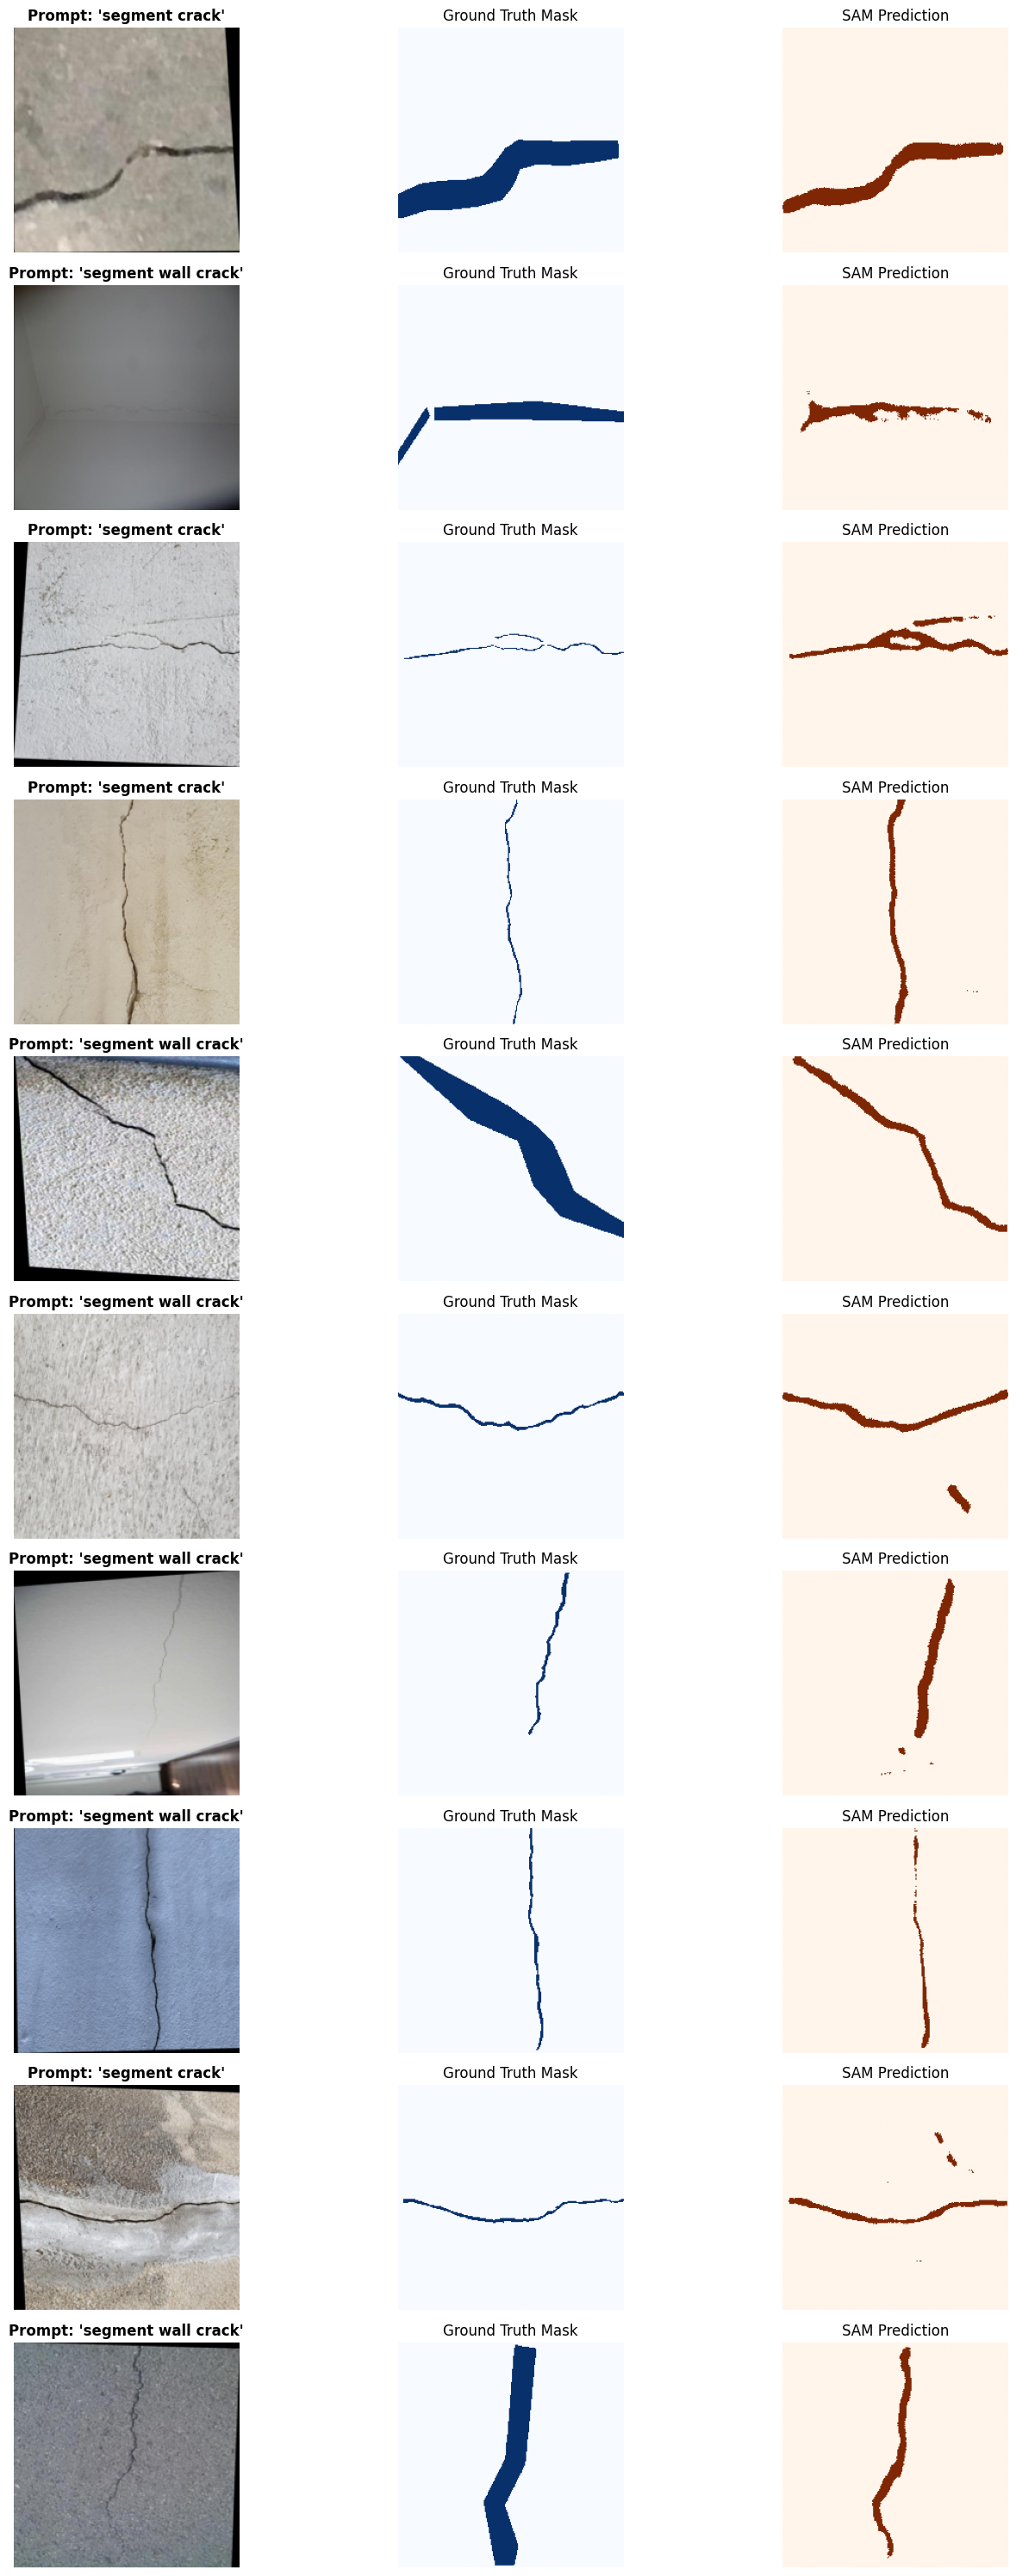

In [6]:
import matplotlib.pyplot as plt

# --- INDEPENDENT TEST EVALUATION AND PLOTTING ---
print("Loading Best Model Checkpoint for Final Test Evaluation...")
model.load_state_dict(torch.load("best_sam_model.pth"))
model.eval()

# 1. Test Dataset Metrics Trackers
test_loss = 0
v_inter, v_psum, v_tsum = 0.0, 0.0, 0.0

with torch.no_grad():
    for images, masks, prompts in tqdm(test_loader, desc="Test Set Evaluation"):
        images, masks = images.to(cfg.DEVICE, non_blocking=True), masks.to(cfg.DEVICE, non_blocking=True)
        text_emb = torch.stack([text_cache[p][0] for p in prompts])
        
        out = model(images, text_emb)
        loss = criterion(out, masks) + 0.1 * (1 - (2*(out*masks).sum()+1e-8)/(out.sum()+masks.sum()+1e-8))
        test_loss += loss.item()
        
        p = (out > 0.5).float().flatten(1)
        t = (masks > 0.5).float().flatten(1)
        v_inter += (p * t).sum().item()
        v_psum += p.sum().item()
        v_tsum += t.sum().item()

# Compute Final Test Scores
test_loss = test_loss / len(test_loader)
test_iou  = (v_inter + 1e-8) / (v_psum + v_tsum - v_inter + 1e-8)
test_prec = (v_inter + 1e-8) / (v_psum + 1e-8)
test_rec  = (v_inter + 1e-8) / (v_tsum + 1e-8)
test_f1   = 2 * test_prec * test_rec / (test_prec + test_rec + 1e-8)
test_dice = (2 * v_inter + 1e-8) / (v_psum + v_tsum + 1e-8)

print("\n" + "="*80)
print(f"FINAL INDEPENDENT TEST SET SCORECARD")
print("="*80)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test IoU:  {test_iou:.4f}")
print(f"Test mIoU: {test_iou:.4f}")
print(f"Precision: {test_prec:.4f}")
print(f"Recall:    {test_rec:.4f}")
print(f"F1 Score:  {test_f1:.4f}")
print(f"Dice:      {test_dice:.4f}")
print("="*80)

# 2. Plot 10 Examples seamlessly
fig, axes = plt.subplots(10, 3, figsize=(15, 30))
examples_shown = 0

with torch.no_grad():
    # Loop over the test loader again just for visuals
    for images, masks, prompts in test_loader:
        images_cuda = images.to(cfg.DEVICE)
        text_emb = torch.stack([text_cache[p][0] for p in prompts])
        preds = model(images_cuda, text_emb)
        
        for i in range(len(images)):
            if examples_shown >= 10: break
            
            # Column 1: Image + Prompt
            original = images[i].permute(1, 2, 0).numpy()
            axes[examples_shown, 0].imshow(original)
            axes[examples_shown, 0].set_title(f"Prompt: '{prompts[i]}'", fontweight="bold")
            axes[examples_shown, 0].axis("off")
            
            # Column 2: Ground Truth
            gt_mask = masks[i].squeeze().numpy()
            axes[examples_shown, 1].imshow(gt_mask, cmap="Blues")
            axes[examples_shown, 1].set_title("Ground Truth Mask")
            axes[examples_shown, 1].axis("off")
            
            # Column 3: SAM's Output
            pred_mask = (preds[i].cpu().squeeze().numpy() > 0.5).astype(np.float32)
            axes[examples_shown, 2].imshow(pred_mask, cmap="Oranges")
            axes[examples_shown, 2].set_title("SAM Prediction")
            axes[examples_shown, 2].axis("off")
            
            examples_shown += 1
            
        if examples_shown >= 10: break

plt.tight_layout()
plt.show()
